<a href="https://colab.research.google.com/github/auravenomfalcon-art/Case_Study/blob/main/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

In [13]:
filepath = '/content/drive/MyDrive/Colab Notebooks/House_Pricing (1).csv'
df_house = pd.read_csv(filepath)
df_house.head(2)

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639


In [14]:
df_house.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [15]:
df_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [16]:
df_house.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [17]:
#Finding the duplicated rows
df_house.duplicated().sum()

np.int64(0)

In [18]:
# Droping the Duplicated rows if any
df_house.drop_duplicates(inplace=True)

In [19]:
#Finding the duplicated columns
df_house.T.duplicated().sum()

np.int64(0)

In [20]:
# Finding the missing values
df_house.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [21]:
# fetching numerical columns and categorical columns
num_cols = df_house.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_house.select_dtypes(include=['object']).columns
print(num_cols)
print(cat_cols)

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')
Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')


In [22]:
# For numerical columns, use imputation techniques like median imputation
for col in num_cols:
    if df_house[col].isnull().sum() > 0:
        df_house[col].fillna(df_house[col].median())

In [23]:
 # For numerical columns, use imputation techniques like mean imputation
 df_house[col].fillna(df_house[col].mean())

,Lot Area after Renovation (in Sqft)
0,5650
1,7639
2,8062
3,5000
4,7503
...,...
21608,1509
21609,7200
21610,2007
21611,1287


In [24]:
df_house.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [25]:
# For categorical columns, fill with mode
for col in cat_cols:
    if df_house[col].isnull().sum() > 0:
        df_house[col].fillna(df_house[col].mode()[0])

In [26]:
# Identify all numerical columns (excluding the target variable SalePrice).
num_cols = df_house.select_dtypes(include=['int64', 'float64']).columns
# num_cols = num_cols.drop('Sale Price')
print(num_cols)

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')


In [27]:
# Scale these features using techniques like Min-Max scaling.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_house[num_cols] = scaler.fit_transform(df_house[num_cols])

In [28]:
df_house.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.720103,14 October 2017,0.019266,0.090909,0.12500,0.067170,0.003108,0.0,No,NaN,...,0.666667,0.097588,0.000000,0.521739,0.000000,0.893939,0.571498,0.217608,0.161934,0.005742
1,0.647853,14 December 2017,0.060721,0.090909,0.28125,0.172075,0.004072,0.4,No,NaN,...,0.666667,0.206140,0.082988,0.556522,0.988089,0.626263,0.908959,0.166113,0.222165,0.008027
2,0.568795,15 February 2016,0.013770,0.060606,0.12500,0.036226,0.005743,0.0,No,NaN,...,0.555556,0.052632,0.000000,0.713043,0.000000,0.136364,0.936143,0.237542,0.399415,0.008513
3,0.251157,14 December 2017,0.069377,0.121212,0.37500,0.126038,0.002714,0.0,No,NaN,...,0.666667,0.083333,0.188797,0.434783,0.000000,0.681818,0.586939,0.104651,0.165376,0.004996
4,0.197333,15 February 2016,0.057049,0.090909,0.25000,0.104906,0.004579,0.0,No,NaN,...,0.777778,0.152412,0.000000,0.243478,0.000000,0.368687,0.741354,0.393688,0.241094,0.007871


In [29]:
# Scale these features using techniques like Standard scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_house[num_cols] = scaler.fit_transform(df_house[num_cols])

In [30]:
df_house.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.886146,14 October 2017,-0.866400,-0.398737,-1.447478,-0.979820,-0.228298,-0.915427,No,NaN,...,-0.564013,-0.734748,-0.658681,0.544898,-0.210128,1.870176,-0.352533,-0.306110,-0.943318,-0.260715
1,0.637511,14 December 2017,-0.005984,-0.398737,0.175645,0.533572,-0.189869,0.936506,No,NaN,...,-0.564013,0.460957,0.245141,0.681079,4.746678,0.879599,1.161593,-0.746368,-0.432658,-0.187868
2,0.365444,15 February 2016,-0.980451,-1.473959,-1.447478,-1.426216,-0.123294,-0.915427,No,NaN,...,-1.468651,-1.229939,-0.658681,1.293892,-0.210128,-0.933343,1.283560,-0.135688,1.070139,-0.172375
3,-0.727656,14 December 2017,0.173666,0.676485,1.149518,-0.130578,-0.243988,-0.915427,No,NaN,...,-0.564013,-0.891759,1.397515,0.204446,-0.210128,1.085190,-0.283250,-1.271837,-0.914137,-0.284522
4,-0.912881,15 February 2016,-0.082199,-0.398737,-0.148980,-0.435434,-0.169641,-0.915427,No,NaN,...,0.340626,-0.130856,-0.658681,-0.544548,-0.210128,-0.073597,0.409582,1.199288,-0.272165,-0.192849


In [31]:
# fetching categorical columns

cat_cols = df_house.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')


In [32]:
# Use One-Hot Encoding for nominal categories.
feature_cat_cols = ['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House']

In [33]:
df_house['Date House was Sold'].unique()

array(['14 October 2017', '14 December 2017', '15 February 2016',
       '14 May 2017', '14 June 2017', '15 January 2016', '15 April 2016',
       '15 March 2016', '14 July 2017', '14 August 2017',
       '14 November 2017', '14 September 2017', '15 May 2016'],
      dtype=object)

In [34]:
df_house['Waterfront View'].unique()


array(['No', 'Yes'], dtype=object)

In [35]:
df_house['No of Times Visited'].unique()

array([nan, 'Thrice', 'Four', 'Twice', 'Once'], dtype=object)

In [36]:
df_house['Condition of the House'].unique()

array(['Fair', 'Excellent', 'Good', 'Bad', 'Okay'], dtype=object)

In [37]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
ohe_cols = ['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House']
df_house_ohe = pd.get_dummies(df_house, columns = ohe_cols, dtype = int)
df_house_ohe.head()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),...,Waterfront View_Yes,No of Times Visited_Four,No of Times Visited_Once,No of Times Visited_Thrice,No of Times Visited_Twice,Condition of the House_Bad,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,0.886146,-0.866400,-0.398737,-1.447478,-0.979820,-0.228298,-0.915427,-0.564013,-0.734748,-0.658681,...,0,0,0,0,0,0,0,1,0,0
1,0.637511,-0.005984,-0.398737,0.175645,0.533572,-0.189869,0.936506,-0.564013,0.460957,0.245141,...,0,0,0,0,0,0,0,1,0,0
2,0.365444,-0.980451,-1.473959,-1.447478,-1.426216,-0.123294,-0.915427,-1.468651,-1.229939,-0.658681,...,0,0,0,0,0,0,0,1,0,0
3,-0.727656,0.173666,0.676485,1.149518,-0.130578,-0.243988,-0.915427,-0.564013,-0.891759,1.397515,...,0,0,0,0,0,0,1,0,0,0
4,-0.912881,-0.082199,-0.398737,-0.148980,-0.435434,-0.169641,-0.915427,0.340626,-0.130856,-0.658681,...,0,0,0,0,0,0,0,1,0,0


In [38]:
label_encoder_obj = LabelEncoder()

df_house['No of Times Visited'] = label_encoder_obj.fit_transform(df_house['No of Times Visited'])

df_house['Condition of the House'] = label_encoder_obj.fit_transform(df_house['Condition of the House'])
df_house.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.886146,14 October 2017,-0.866400,-0.398737,-1.447478,-0.979820,-0.228298,-0.915427,No,4,...,-0.564013,-0.734748,-0.658681,0.544898,-0.210128,1.870176,-0.352533,-0.306110,-0.943318,-0.260715
1,0.637511,14 December 2017,-0.005984,-0.398737,0.175645,0.533572,-0.189869,0.936506,No,4,...,-0.564013,0.460957,0.245141,0.681079,4.746678,0.879599,1.161593,-0.746368,-0.432658,-0.187868
2,0.365444,15 February 2016,-0.980451,-1.473959,-1.447478,-1.426216,-0.123294,-0.915427,No,4,...,-1.468651,-1.229939,-0.658681,1.293892,-0.210128,-0.933343,1.283560,-0.135688,1.070139,-0.172375
3,-0.727656,14 December 2017,0.173666,0.676485,1.149518,-0.130578,-0.243988,-0.915427,No,4,...,-0.564013,-0.891759,1.397515,0.204446,-0.210128,1.085190,-0.283250,-1.271837,-0.914137,-0.284522
4,-0.912881,15 February 2016,-0.082199,-0.398737,-0.148980,-0.435434,-0.169641,-0.915427,No,4,...,0.340626,-0.130856,-0.658681,-0.544548,-0.210128,-0.073597,0.409582,1.199288,-0.272165,-0.192849


In [39]:
df_house.shape

(21613, 21)

In [40]:
# Perform an outlier detection analysis on numerical variables (e.g., using the IQR method).

for col in num_cols:
    Q1 = df_house[col].quantile(0.25)
    Q3 = df_house[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_house[(df_house[col] < lower_bound) | (df_house[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

ID: 0 outliers
Sale Price: 1159 outliers
No of Bedrooms: 546 outliers
No of Bathrooms: 571 outliers
Flat Area (in Sqft): 572 outliers
Lot Area (in Sqft): 2423 outliers
No of Floors: 0 outliers
Overall Grade: 1911 outliers
Area of the House from Basement (in Sqft): 610 outliers
Basement Area (in Sqft): 496 outliers
Age of House (in Years): 0 outliers
Renovated Year: 914 outliers
Zipcode: 0 outliers
Latitude: 2 outliers
Longitude: 256 outliers
Living Area after Renovation (in Sqft): 544 outliers
Lot Area after Renovation (in Sqft): 2194 outliers


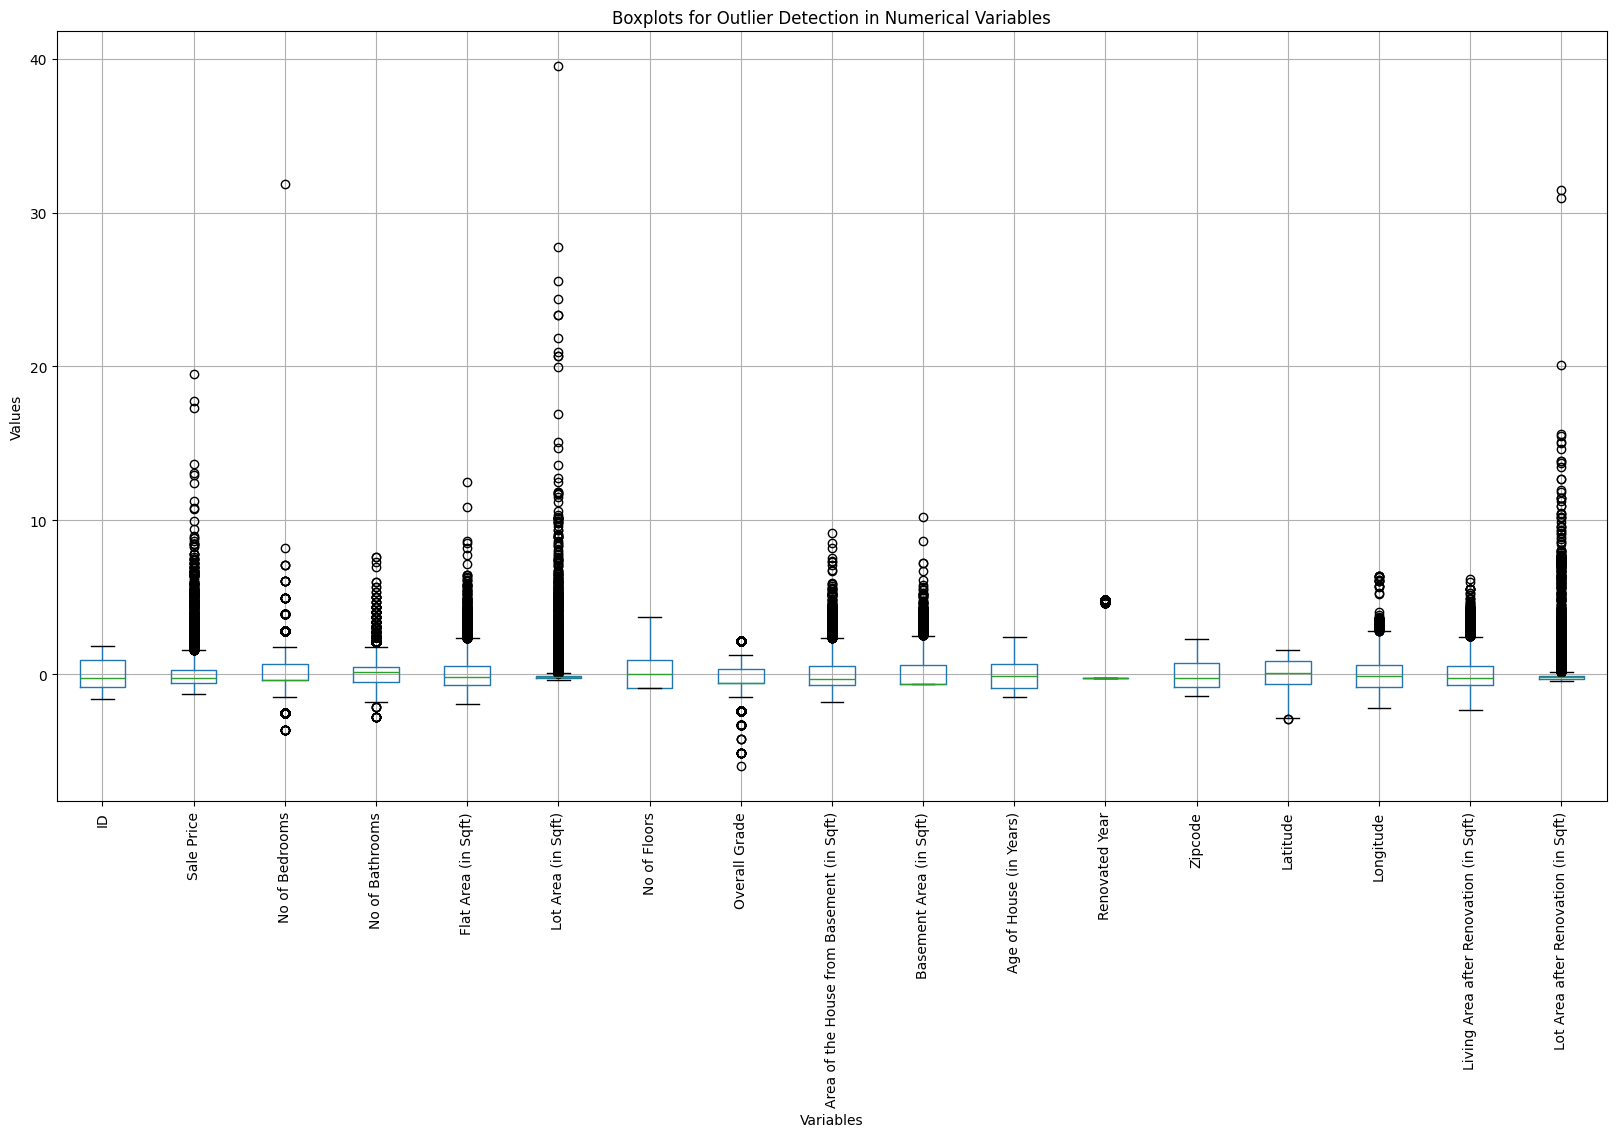

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
df_house[num_cols].boxplot(rot=90)

plt.title('Boxplots for Outlier Detection in Numerical Variables')
plt.xlabel('Variables')
plt.ylabel('Values')
plt.show()

In [42]:
# Remove outliers from these features if they are not representative of typical house prices.
for col in num_cols:
    Q1 = df_house[col].quantile(0.25)
    Q3 = df_house[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_house = df_house[(df_house[col] >= lower_bound) & (df_house[col] <= upper_bound)]

    print(f"{col}: Shape after removing outliers", df_house.shape)

ID: Shape after removing outliers (21613, 21)
Sale Price: Shape after removing outliers (20450, 21)
No of Bedrooms: Shape after removing outliers (19969, 21)
No of Bathrooms: Shape after removing outliers (19837, 21)
Flat Area (in Sqft): Shape after removing outliers (19571, 21)
Lot Area (in Sqft): Shape after removing outliers (17514, 21)
No of Floors: Shape after removing outliers (17514, 21)
Overall Grade: Shape after removing outliers (16871, 21)
Area of the House from Basement (in Sqft): Shape after removing outliers (16431, 21)
Basement Area (in Sqft): Shape after removing outliers (16199, 21)
Age of House (in Years): Shape after removing outliers (16199, 21)
Renovated Year: Shape after removing outliers (15626, 21)
Zipcode: Shape after removing outliers (15626, 21)
Latitude: Shape after removing outliers (15625, 21)
Longitude: Shape after removing outliers (15281, 21)
Living Area after Renovation (in Sqft): Shape after removing outliers (15136, 21)
Lot Area after Renovation (in 

In [43]:
# Set aside the SalePrice column as the target variable.
target = df_house['Sale Price']

# Feature variables
X = df_house.drop('Sale Price', axis=1)

print("Features shape:", X.shape)
print("Target shape:", target.shape)

Features shape: (14818, 20)
Target shape: (14818,)


In [44]:
# Split the dataset into training (80%) and testing (20%) sets using the train_test_split function from sklearn.
from sklearn.model_selection import train_test_split
X_train, X_test, target_train, target_test = train_test_split(
    X,              # Feature variables
    target,              # Target variable (SalePrice)
    test_size=0.2,  # 20% test data
    random_state=42 # For reproducibility
)

# Display the shapes of the resulting datasets
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", target_train.shape)
print("Testing Target Shape:", target_test.shape)

Training Features Shape: (11854, 20)
Testing Features Shape: (2964, 20)
Training Target Shape: (11854,)
Testing Target Shape: (2964,)
